In [104]:
import numpy as np
import matplotlib.pyplot as plt
from neurodsp.sim import sim_powerlaw
from neurodsp.utils import set_random_seed
from scipy.signal import decimate, stft, welch
from fooof import FOOOF
from fooof.sim.gen import gen_aperiodic
from scipy.stats import spearmanr
from scipy.stats import pearsonr

In [71]:
# Set random seed for reproducibility
set_random_seed(42)


In [121]:
?sim_powerlaw

In [122]:
def run_simulation(offset, exponent, n_trials=100, n_seconds=0.45, fs_original=40000, fs_downsampled=2000):
    # Generate 100 trials of aperiodic signals
    trials = np.array([sim_powerlaw(n_seconds, fs_original, exponent) for _ in range(n_trials)])

    dwnsmpl_fctr = int(fs_original / fs_downsampled)
    ds_trials = decimate(trials, dwnsmpl_fctr, n=None, ftype='fir', axis=-1)
    
    return ds_trials

def compute_psd(trial_data, fs, method, winsize=128, overlap=None, fft_length=None, freq_lims=(0.5, 250)):
    if overlap is None:
        overlap = int(winsize*7/8)
    if fft_length is None:
        fft_length = int(winsize*16)
    if method=='welch':
        freqs,psd_trials=welch(
            trial_data, 
            fs=fs, 
            window='hann', 
            nperseg=winsize, 
            noverlap=overlap, 
            nfft=fft_length, 
            detrend='constant',
            return_onesided=True, 
            scaling='density', 
            axis=- 1, 
            average='mean'
        )
    elif method=='stft':
        freqs, times, Zxx = stft(
            trial_data, 
            fs=fs, 
            window='hann', 
            nperseg=winsize,
            noverlap=overlap, 
            nfft=fft_length, 
            detrend='constant',
            return_onesided=True, 
            axis=-1
        )
        psd_trials=np.mean(np.abs(Zxx) ** 2,axis=-1)

    # Select frequency range
    f_idx = (freqs >= freq_lims[0]) & (freqs < freq_lims[1])
    freqs = freqs[f_idx]
    psd_trials=psd_trials[:,f_idx]
    
    return freqs, psd_trials

In [123]:
fs_downsampled=500
trial_data=run_simulation(0,-2,fs_downsampled=fs_downsampled)


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Welch: offset=0.9954331930613005
Welch: slope=2.315473410907476

FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

STFT: offset=2.101566567476632
STFT: slope=2.3250217302536815


Text(0, 0.5, 'Power')

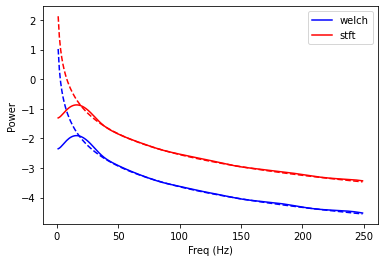

In [129]:
foi, welch_psd=compute_psd(trial_data, fs_downsampled, 'welch')
foi, stft_psd=compute_psd(trial_data, fs_downsampled, 'stft')

f_welch = FOOOF()
f_welch.fit(foi, np.mean(welch_psd,axis=0), [50,150])
print(f'Welch: offset={f_welch.aperiodic_params_[0]}')
print(f'Welch: slope={f_welch.aperiodic_params_[1]}')
aper_welch = gen_aperiodic(foi, f_welch.aperiodic_params_)

f_stft = FOOOF()
f_stft.fit(foi, np.mean(stft_psd,axis=0), [50,150])
print(f'STFT: offset={f_stft.aperiodic_params_[0]}')
print(f'STFT: slope={f_stft.aperiodic_params_[1]}')
aper_stft = gen_aperiodic(foi, f_stft.aperiodic_params_)

plt.figure()
ax=plt.subplot(1,1,1)
ax.plot(foi,np.log10(np.mean(welch_psd,axis=0)),'b', label='welch')
ax.plot(foi, aper_welch,'b--')
ax.plot(foi,np.log10(np.mean(stft_psd,axis=0)), 'r', label='stft')
ax.plot(foi, aper_stft,'r--')
plt.legend()
plt.xlabel('Freq (Hz)')
plt.ylabel('Power')

In [134]:
slopes=np.arange(0,2.5,.25)
est_welch_slopes=[]
est_stft_slopes=[]
for slope in slopes:
    trial_data=run_simulation(0,-1*slope,fs_downsampled=500, n_seconds=.225)
    
    foi, welch_psd=compute_psd(trial_data, fs_downsampled, 'welch')
    foi, stft_psd=compute_psd(trial_data, fs_downsampled, 'stft')

    f_welch = FOOOF()
    f_welch.fit(foi, np.mean(welch_psd,axis=0), [50,100])
    est_welch_slopes.append(f_welch.aperiodic_params_[1])

    f_stft = FOOOF()
    f_stft.fit(foi, np.mean(stft_psd,axis=0), [50,100])
    est_stft_slopes.append(f_stft.aperiodic_params_[1])


/home/bonaiuto/miniconda3/envs/hnn/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:1999: UserWarning: nperseg = 128 is greater than input length  = 113, using nperseg = 113
  warnings.warn('nperseg = {0:d} is greater than input length '



FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



/home/bonaiuto/miniconda3/envs/hnn/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:1999: UserWarning: nperseg = 128 is greater than input length  = 113, using nperseg = 113
  warnings.warn('nperseg = {0:d} is greater than input length '



FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



/home/bonaiuto/miniconda3/envs/hnn/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:1999: UserWarning: nperseg = 128 is greater than input length  = 113, using nperseg = 113
  warnings.warn('nperseg = {0:d} is greater than input length '


...


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



/home/bonaiuto/miniconda3/envs/hnn/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:1999: UserWarning: nperseg = 128 is greater than input length  = 113, using nperseg = 113
  warnings.warn('nperseg = {0:d} is greater than input length '



FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



/home/bonaiuto/miniconda3/envs/hnn/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:1999: UserWarning: nperseg = 128 is greater than input length  = 113, using nperseg = 113
  warnings.warn('nperseg = {0:d} is greater than input length '



FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



Text(0, 0.5, 'estimated slope')

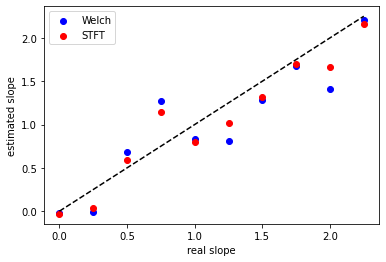

In [135]:
plt.scatter(slopes, est_welch_slopes,color='b',label='Welch')
plt.scatter(slopes, est_stft_slopes,color='r',label='STFT')
plt.plot([slopes[0], slopes[-1]],[slopes[0], slopes[-1]],'k--')
plt.legend()
plt.xlabel('real slope')
plt.ylabel('estimated slope')

In [115]:
rmse=np.sqrt(np.mean((slopes-est_welch_slopes)**2))
print(f"Welch RMSE: {rmse:.4f}")
rmse=np.sqrt(np.mean((slopes-est_stft_slopes)**2))
print(f"STFT RMSE: {rmse:.4f}")

Welch RMSE: 3.4543
STFT RMSE: 3.2235


In [105]:
trial_durs=[0.5, 1.0, 2.0]
slopes=np.arange(-5,0,.25)
corrs=[]
for trial_dur in trial_durs:
    welch_slopes=[]
    for slope in slopes:
        trial_data=run_simulation(0,slope,fs_downsampled=fs_downsampled,n_seconds=trial_dur)

        foi, welch_psd=compute_psd(trial_data, fs_downsampled, 'welch')
        
        f_welch = FOOOF()
        f_welch.fit(foi, np.mean(welch_psd,axis=0), [50,250])
        welch_slopes.append(f_welch.aperiodic_params_[1])
    spearman_corr, p_value = spearmanr(-1 * slopes, est_welch_slopes)
    pearson_corr, p_value = pearsonr(-1 * slopes, est_welch_slopes)
    #corrs.append(spearman_corr)
    corrs.append(pearson_corr)


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.98 <= 0.50
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low

Text(0, 0.5, 'Correlation')

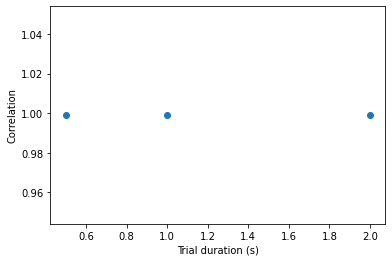

In [107]:
plt.scatter(trial_durs,corrs)
plt.xlabel('Trial duration (s)')
plt.ylabel('Correlation')

In [103]:
corrs

[1.0, 1.0, 1.0]